# Pipeline de Pré-processamento
**Objetivo:** Estruturar o pipeline de dados para excluir coluna que gerará ruído, montar os dados de treinamento/teste e transformar os textos em números.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import os

PROCESSED_PATH = '../data/processed/dataset_limpo.csv'

df = pd.read_csv(PROCESSED_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 65231 entries, 0 to 65230
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Distribuidora         65231 non-null  str    
 1   Protocolo             65231 non-null  int64  
 2   Natureza              65231 non-null  str    
 3   Tipologia             65231 non-null  str    
 4   CanalEntrada          65231 non-null  str    
 5   tempo_resolucao_dias  65231 non-null  float64
 6   estourou_sla          65231 non-null  int64  
 7   dia_semana_abertura   65231 non-null  int64  
 8   hora_abertura         65231 non-null  int64  
 9   mes_abertura          65231 non-null  int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 5.0 MB


In [2]:
df = df.drop(columns=['Protocolo'])


In [3]:
X = df.drop(columns=["estourou_sla"])
y = df["estourou_sla"]
            

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")

Treino: 52184 amostras
Teste: 13047 amostras


In [5]:
colunas_de_texto = ['Distribuidora', 'Natureza', 'Tipologia', 'CanalEntrada']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_de_texto)
    ],
    remainder='passthrough'
)

# Pipeline de Treinamento
Utiliza o mesmo pre-processador para o tratamento dos dados e treina os dois modelos.

In [6]:
## Modelo de Classificação
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline_classificacao = Pipeline(steps=[
    ('preprocessor', preprocessor), # O pré-processador da Issue 4
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

pipeline_classificacao.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [7]:
## Modelo de Regressão
from sklearn.ensemble import RandomForestRegressor

pipeline_regressao = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

pipeline_regressao.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

=== Classification Report — Modelo SLA ===
              precision    recall  f1-score   support

No Prazo (0)       1.00      1.00      1.00     12498
Atrasado (1)       1.00      1.00      1.00       549

    accuracy                           1.00     13047
   macro avg       1.00      1.00      1.00     13047
weighted avg       1.00      1.00      1.00     13047



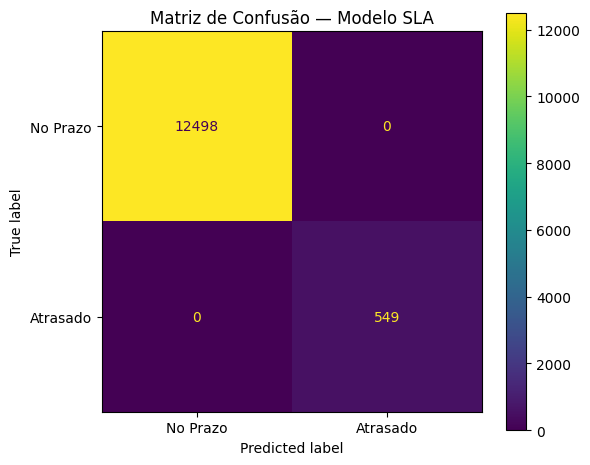

In [8]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predições no conjunto de TESTE (dados nunca vistos)
y_pred_clf = pipeline_classificacao.predict(X_test)

# Classification Report
print("=== Classification Report — Modelo SLA ===")
print(classification_report(y_test, y_pred_clf, target_names=["No Prazo (0)", "Atrasado (1)"]))

# Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clf,
    display_labels=["No Prazo", "Atrasado"], ax=ax)
plt.title("Matriz de Confusão — Modelo SLA")
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Split específico para regressão
X_reg = df.drop(columns=["tempo_resolucao_dias", "estourou_sla"])
y_reg = df["tempo_resolucao_dias"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

pipeline_regressao.fit(X_train_r, y_train_r)
y_pred_reg = pipeline_regressao.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))

print(f"MAE:  {mae:.2f} dias  →  o modelo erra em média {mae:.1f} dias")
print(f"RMSE: {rmse:.2f} dias  →  erros grandes são penalizados aqui")

MAE:  5.86 dias  →  o modelo erra em média 5.9 dias
RMSE: 23.65 dias  →  erros grandes são penalizados aqui


In [11]:
import pandas as pd

# Reconstruir X_test com colunas originais para leitura humana
X_test_legivel = X_test.copy()
X_test_legivel['real'] = y_test.values
X_test_legivel['previsto'] = y_pred_clf
X_test_legivel['acertou'] = X_test_legivel['real'] == X_test_legivel['previsto']

# Filtrar: errou na classe 1 (o pior tipo — disse "no prazo" mas era "atrasado")
falsos_negativos = X_test_legivel[
    (X_test_legivel['real'] == 1) & (X_test_legivel['previsto'] == 0)
]

print(f"Total de Falsos Negativos: {len(falsos_negativos)}")
print("\n=== 3 exemplos de erros graves ===")
falsos_negativos[['Distribuidora', 'Tipologia', 'CanalEntrada', 
                   'dia_semana_abertura', 'real', 'previsto']].head(3)

Total de Falsos Negativos: 0

=== 3 exemplos de erros graves ===


,Distribuidora,Tipologia,CanalEntrada,dia_semana_abertura,real,previsto
